# Project #4: Risk Analysis for NRI Data
**Team:** 151-05
**Date:** 2026-04-21

**Client:** Department of Homeland Security for the Federal Emergency Management Agency

In [1]:
## Import relevant packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import geopandas as gpd

from PIL import Image
from IPython.display import display

# Calculating Lightning Risk by NRI and Our Risk Score in Colorado by Counties

In [2]:
co_nri = pd.read_csv("NRI_Table_CensusTracts_Colorado.csv")
co_svi = pd.read_csv("Colorado.csv")
nri_dictionary = pd.read_csv("NRIDataDictionary.csv")

In [3]:
co_nri['STCNTY'] = co_nri['STCOFIPS']
co_nri.columns

Index(['OID_', 'NRI_ID', 'STATE', 'STATEABBRV', 'STATEFIPS', 'COUNTY',
       'COUNTYTYPE', 'COUNTYFIPS', 'STCOFIPS', 'TRACT',
       ...
       'WNTW_EALR', 'WNTW_ALRB', 'WNTW_ALRP', 'WNTW_ALRA', 'WNTW_ALR_NPCTL',
       'WNTW_RISKV', 'WNTW_RISKS', 'WNTW_RISKR', 'NRI_VER', 'STCNTY'],
      dtype='object', length=468)

In [4]:
complete_data = pd.merge(co_nri, co_svi, on = 'STCNTY')

In [5]:
complete_data = pd.merge(co_nri, co_svi, on = 'STCNTY', suffixes=('', '_right'))
complete_data.columns

Index(['OID_', 'NRI_ID', 'STATE', 'STATEABBRV', 'STATEFIPS', 'COUNTY',
       'COUNTYTYPE', 'COUNTYFIPS', 'STCOFIPS', 'TRACT',
       ...
       'EP_ASIAN', 'MP_ASIAN', 'EP_AIAN', 'MP_AIAN', 'EP_NHPI', 'MP_NHPI',
       'EP_TWOMORE', 'MP_TWOMORE', 'EP_OTHERRACE', 'MP_OTHERRACE'],
      dtype='object', length=625)

In [6]:

complete_data['CALC_LTNG_RISK'] = (
    (complete_data['LTNG_EALS'] * 0.40) +
    (complete_data['SOVI_SCORE'] * 0.45) +
    ((1 - complete_data['RESL_SCORE']) * 0.15)
)


In [9]:

# Ensure numeric
complete_data["CALC_LTNG_RISK"] = pd.to_numeric(complete_data["CALC_LTNG_RISK"], errors="coerce")
complete_data["LTNG_RISKS"] = pd.to_numeric(complete_data["LTNG_RISKS"], errors="coerce")

# Clean county names
complete_data["COUNTY"] = complete_data["COUNTY"].str.strip()

# Group and compute means
grouped_data = complete_data.groupby("COUNTY").agg(
    mean_lntg_my_risk=("CALC_LTNG_RISK", "mean"),
    mean_lntg_NRI=("LTNG_RISKS", "mean")
)

print(grouped_data.head())

           mean_lntg_my_risk  mean_lntg_NRI
COUNTY                                     
Adams              40.146068      72.546994
Alamosa            67.224011      93.113814
Arapahoe           38.997687      68.977721
Archuleta          65.397622      92.021690
Baca               79.189205      99.230614


In [10]:
### Group your data by county
grouped_data = complete_data.groupby('COUNTY',as_index=False)

## Run summary mean by county
grouped_data = complete_data.groupby('COUNTY').agg(mean_lntg_my_risk=('CALC_LTNG_RISK', 'mean'), 
                                                   mean_lntg_NRI=('LTNG_RISKS', 'mean'))

print(grouped_data)

            mean_lntg_my_risk  mean_lntg_NRI
COUNTY                                      
Adams               40.146068      72.546994
Alamosa             67.224011      93.113814
Arapahoe            38.997687      68.977721
Archuleta           65.397622      92.021690
Baca                79.189205      99.230614
...                       ...            ...
Summit              44.582465      93.512837
Teller              51.966946      99.047929
Washington          47.706029      57.053500
Weld                33.121324      60.339621
Yuma                48.404376      92.249058

[64 rows x 2 columns]


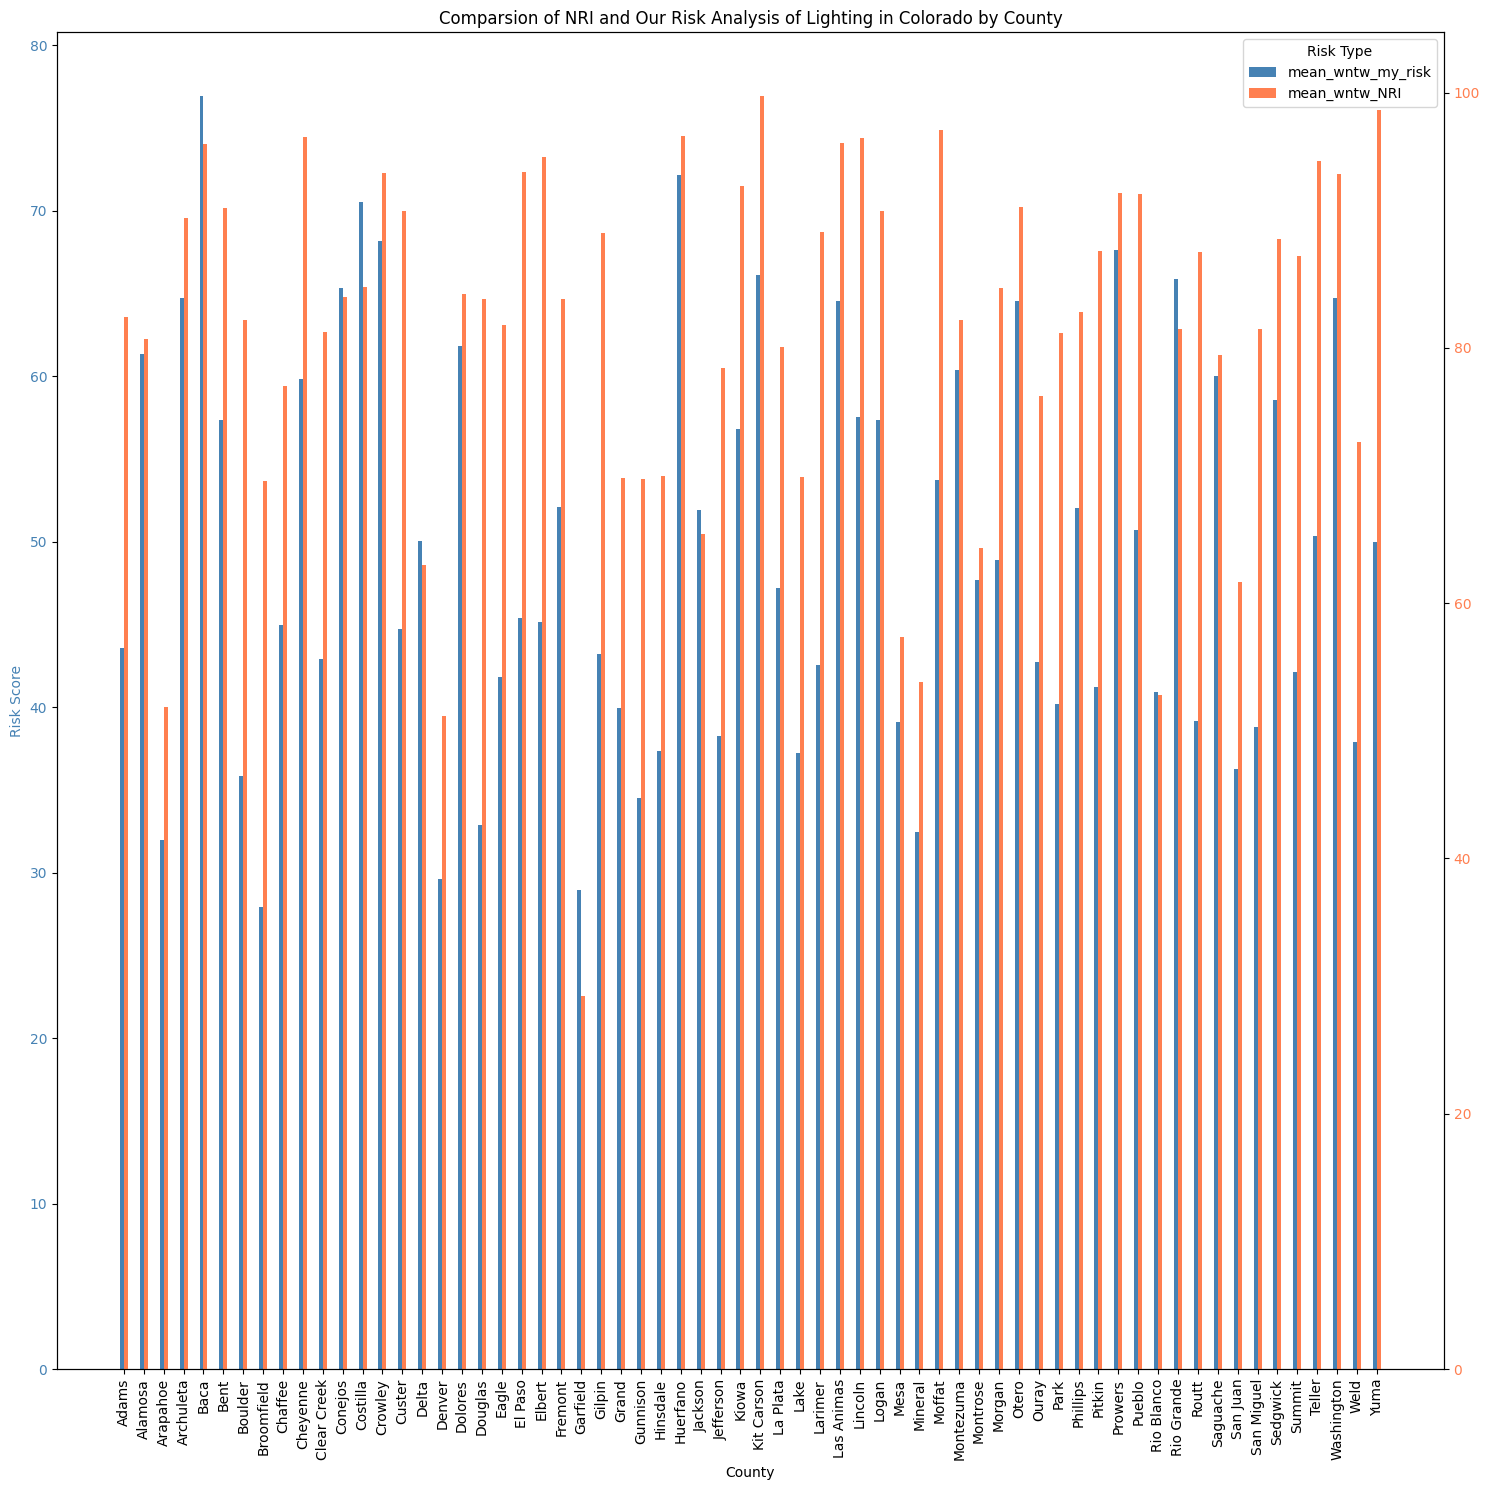

In [55]:
fig, ax1 = plt.subplots(figsize=(15,15))

x = range(len(grouped_data))
width = 0.2
ax1.bar([i-width/2 for i in x], grouped_data.iloc[:, 0], width=width, color ='steelblue', label=grouped_data.columns[0])
ax1.set_ylabel('Risk Score', color='steelblue')
ax1.tick_params(axis='y', labelcolor='steelblue')

ax2 = ax1.twinx()
ax2.bar([i + width/2 for i in x], grouped_data.iloc[:, 1], width=width, color='coral', label=grouped_data.columns[1])
ax2.tick_params(axis = 'y', labelcolor = 'coral')

ax1.set_xticks(x)
ax1.set_xticklabels(grouped_data.index, rotation = 90)
ax1.set_xlabel('County')

plt.title('Comparsion of NRI and Our Risk Analysis of Lighting in Colorado by County')

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, title = 'Risk Type')

plt.tight_layout()
plt.show()

# Calculating Winter Weather Risk by NRI and Our Risk Score in Colorado by Counties

In [51]:

complete_data['CALC_WNTW_RISK'] = (
    (complete_data['WNTW_EALS'] * 0.40) +
    (complete_data['SOVI_SCORE'] * 0.45) +
    ((1 - complete_data['RESL_SCORE']) * 0.15)
)


In [52]:
### Group your data by county
grouped_data = complete_data.groupby('COUNTY',as_index=False)

## Run summary mean by county
grouped_data = complete_data.groupby('COUNTY').agg(mean_wntw_my_risk=('CALC_WNTW_RISK', 'mean'), 
                                                   mean_wntw_NRI=('WNTW_RISKS', 'mean'))

print(grouped_data)

            mean_wntw_my_risk  mean_wntw_NRI
COUNTY                                      
Adams               43.607044      82.400256
Alamosa             61.349761      80.659938
Arapahoe            31.997727      51.840058
Archuleta           64.713773      90.203177
Baca                76.942273      95.976977
...                       ...            ...
Summit              42.138729      87.214450
Teller              50.374554      94.647837
Washington          64.714901      93.590691
Weld                37.900609      72.662187
Yuma                49.967788      98.643302

[64 rows x 2 columns]


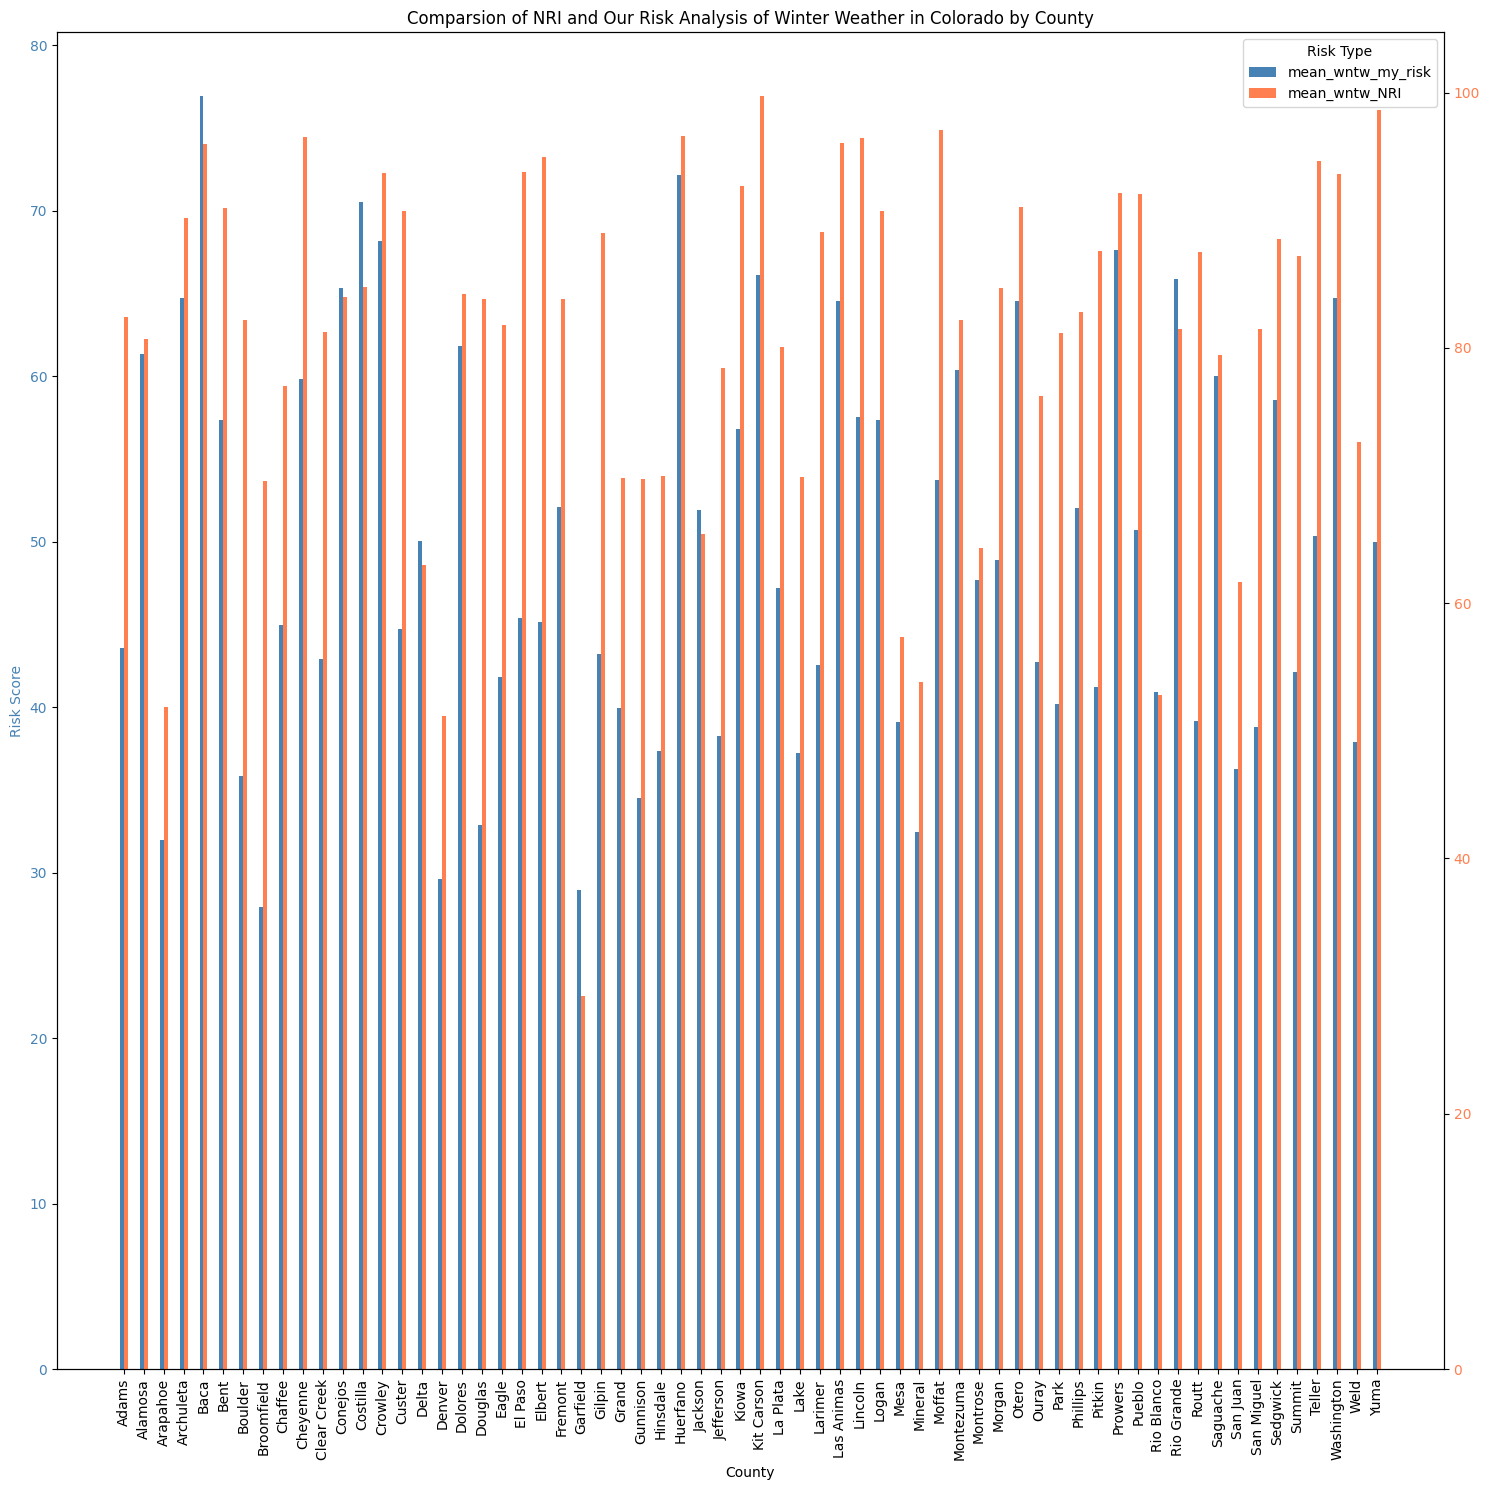

In [54]:
fig, ax1 = plt.subplots(figsize=(15,15))

x = range(len(grouped_data))
width = 0.2
ax1.bar([i-width/2 for i in x], grouped_data.iloc[:, 0], width=width, color ='steelblue', label=grouped_data.columns[0])
ax1.set_ylabel('Risk Score', color='steelblue')
ax1.tick_params(axis='y', labelcolor='steelblue')

ax2 = ax1.twinx()
ax2.bar([i + width/2 for i in x], grouped_data.iloc[:, 1], width=width, color='coral', label=grouped_data.columns[1])
ax2.tick_params(axis = 'y', labelcolor = 'coral')

ax1.set_xticks(x)
ax1.set_xticklabels(grouped_data.index, rotation = 90)
ax1.set_xlabel('County')

plt.title('Comparsion of NRI and Our Risk Analysis of Winter Weather in Colorado by County')

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, title = 'Risk Type')

plt.tight_layout()
plt.show()

# Calculating Heat Wave Risk by NRI and Our Risk Score in Texas by Counties

In [12]:
tx_nri = pd.read_csv("NRI_Table_CensusTracts_Texas.csv", low_memory = False)
tx_svi = pd.read_csv("Texas.csv")
nri_dictionary = pd.read_csv("NRIDataDictionary.csv")

In [13]:
tx_nri['STCNTY'] = tx_nri['STCOFIPS']
tx_nri.columns

Index(['OID_', 'NRI_ID', 'STATE', 'STATEABBRV', 'STATEFIPS', 'COUNTY',
       'COUNTYTYPE', 'COUNTYFIPS', 'STCOFIPS', 'TRACT',
       ...
       'WNTW_EALR', 'WNTW_ALRB', 'WNTW_ALRP', 'WNTW_ALRA', 'WNTW_ALR_NPCTL',
       'WNTW_RISKV', 'WNTW_RISKS', 'WNTW_RISKR', 'NRI_VER', 'STCNTY'],
      dtype='object', length=468)

In [14]:
complete_data_tx = pd.merge(tx_nri, tx_svi, on = 'STCNTY')

In [15]:
complete_data_tx = pd.merge(tx_nri, tx_svi, on = 'STCNTY', suffixes=('', '_right'))
complete_data_tx.columns

Index(['OID_', 'NRI_ID', 'STATE', 'STATEABBRV', 'STATEFIPS', 'COUNTY',
       'COUNTYTYPE', 'COUNTYFIPS', 'STCOFIPS', 'TRACT',
       ...
       'EP_ASIAN', 'MP_ASIAN', 'EP_AIAN', 'MP_AIAN', 'EP_NHPI', 'MP_NHPI',
       'EP_TWOMORE', 'MP_TWOMORE', 'EP_OTHERRACE', 'MP_OTHERRACE'],
      dtype='object', length=625)

In [47]:

complete_data_tx['CALC_HWAV_RISK'] = (
    (complete_data_tx['HWAV_EALS'] * 0.40) +
    (complete_data_tx['SOVI_SCORE'] * 0.45) +
    ((1 - complete_data_tx['RESL_SCORE']) * 0.15)
)


In [48]:
### Group your data by county
grouped_data_tx = complete_data_tx.groupby('COUNTY',as_index=False)

## Run summary mean by county
grouped_data_tx = complete_data_tx.groupby('COUNTY').agg(mean_hwav_my_risk=('CALC_HWAV_RISK', 'mean'), 
                                                   mean_hwav_NRI=('HWAV_RISKS', 'mean'))

print(grouped_data_tx)

          mean_hwav_my_risk  mean_hwav_NRI
COUNTY                                    
Anderson          57.984843      78.475400
Andrews           39.264705      54.538169
Angelina          62.954386      93.557333
Aransas           44.775256      54.831141
Archer            52.543079      75.605367
...                     ...            ...
Wood              63.628780      84.634833
Yoakum            56.784557      55.810572
Young             54.481240      80.942609
Zapata            50.767700      46.696895
Zavala            73.287067      89.037847

[254 rows x 2 columns]


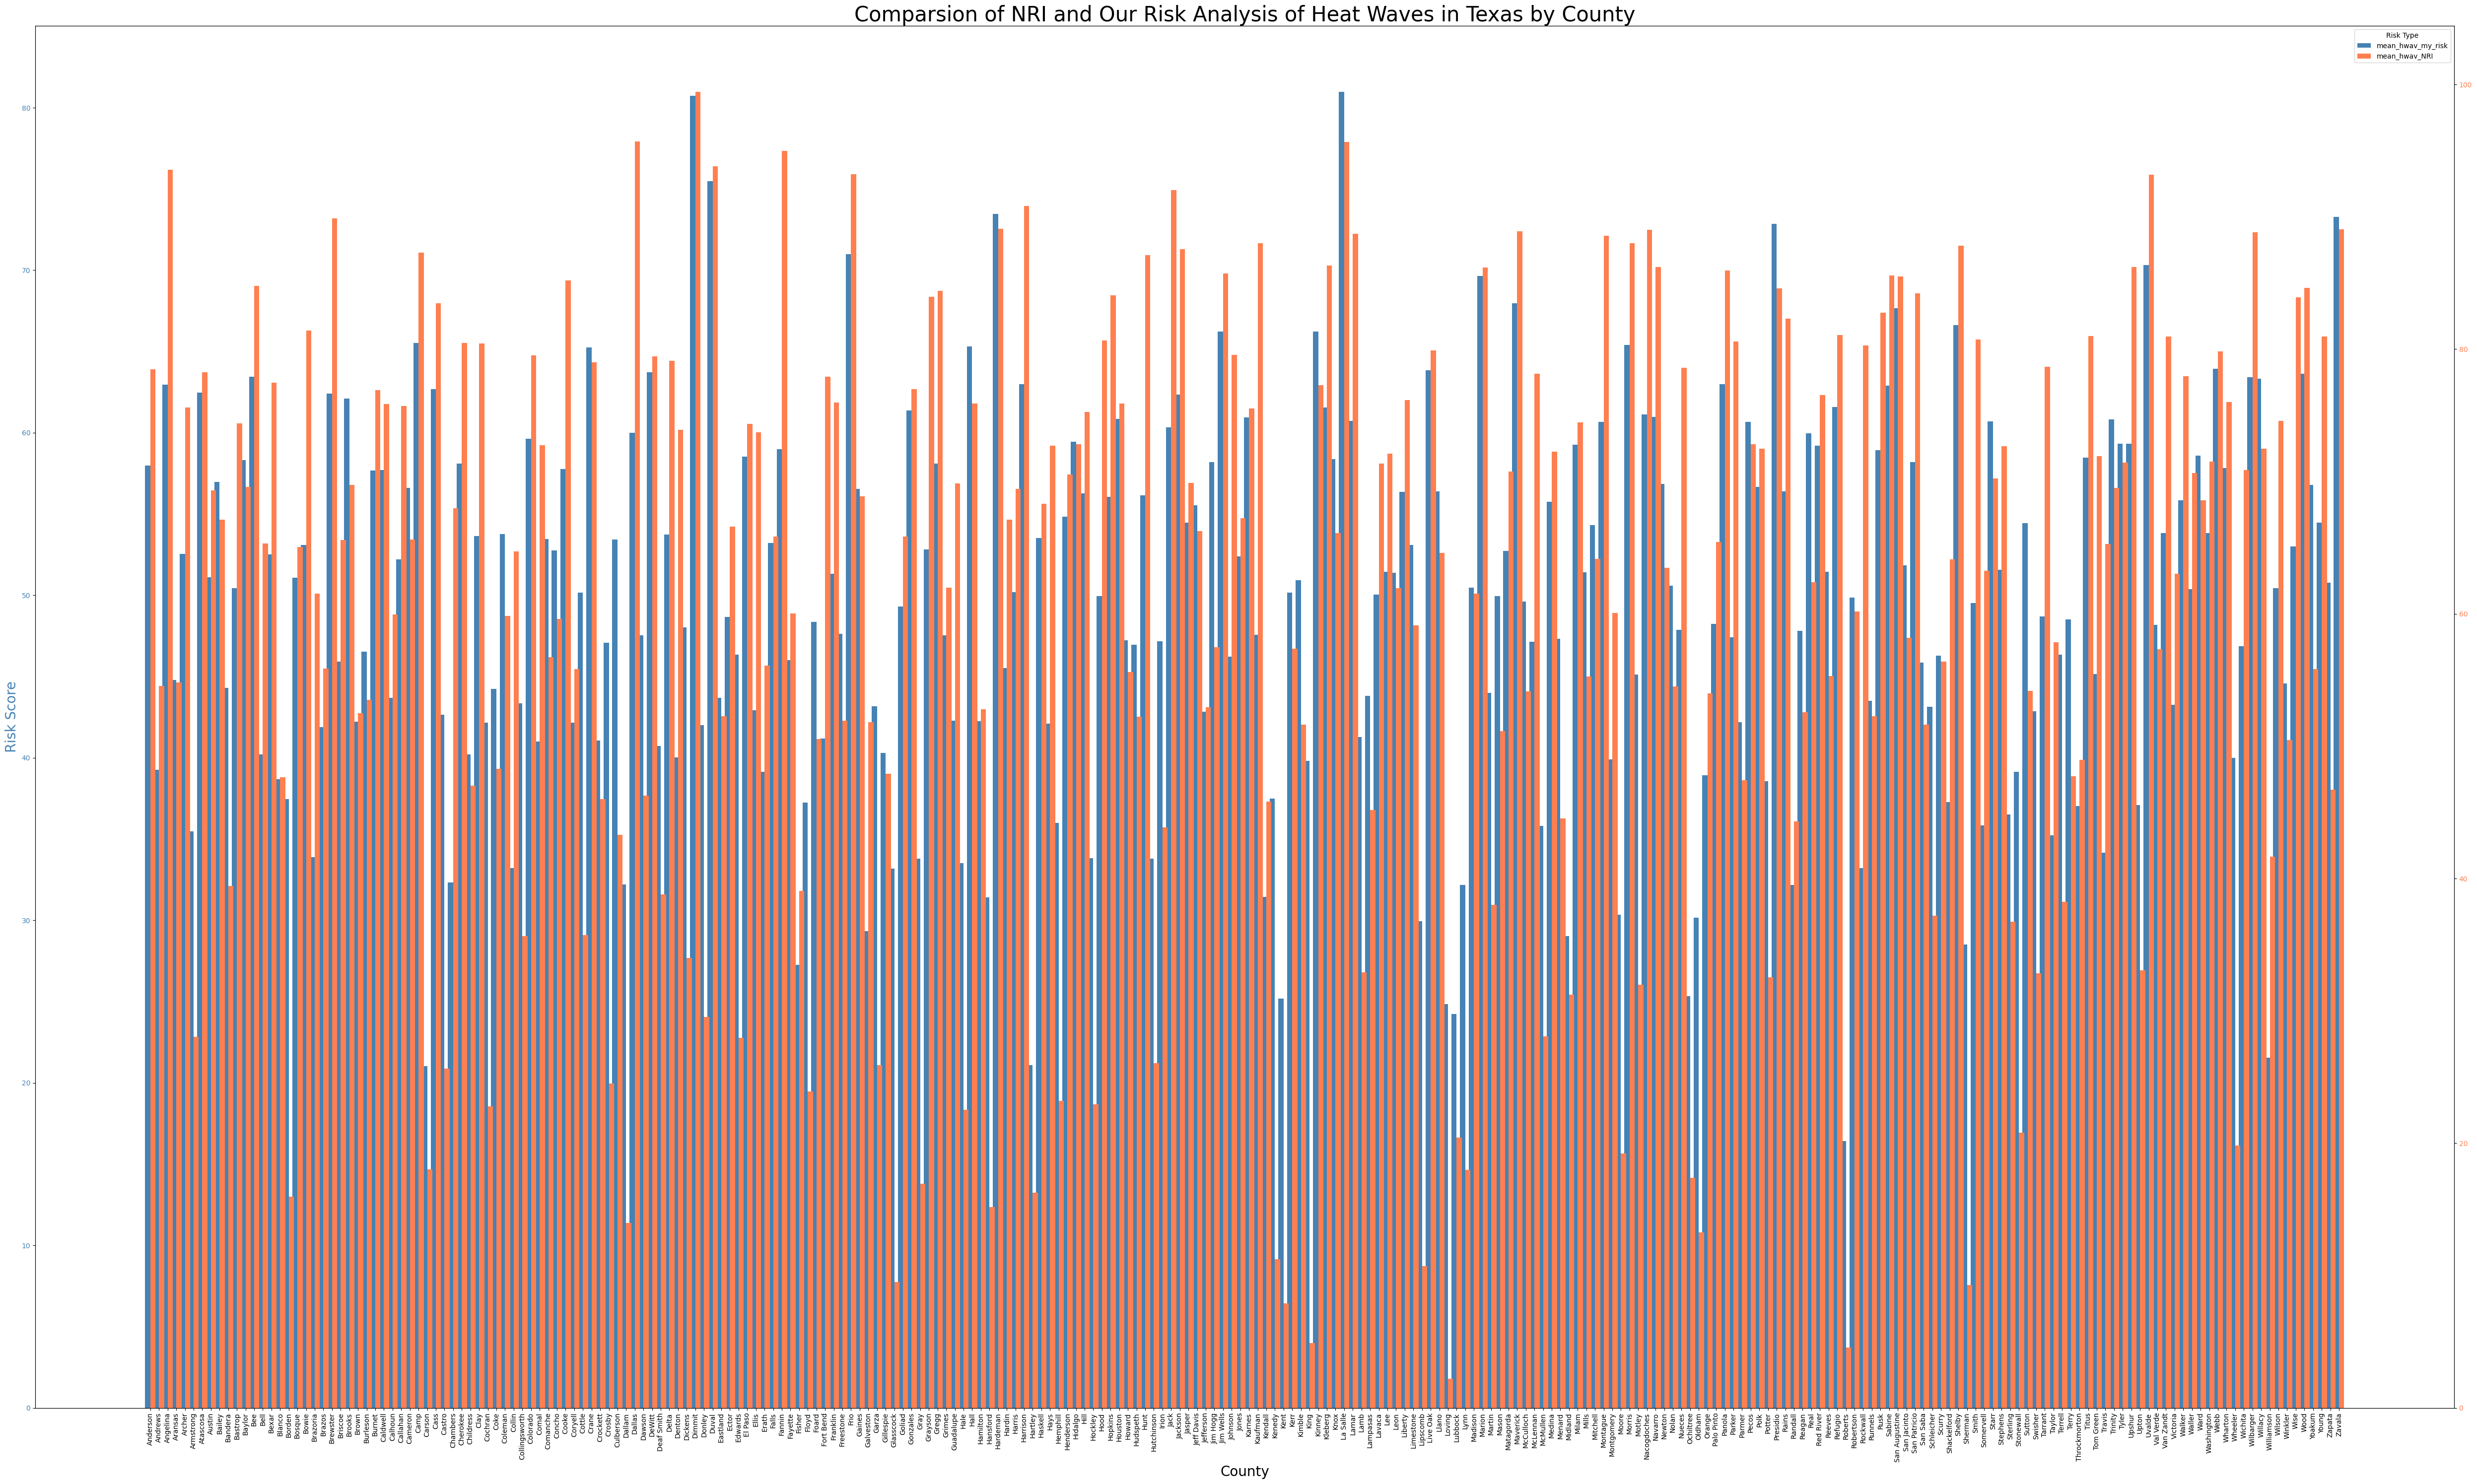

In [49]:
fig, ax1 = plt.subplots(figsize=(50,30))

x = range(len(grouped_data_tx))
width = 0.6
ax1.bar([i-width/2 for i in x], grouped_data_tx.iloc[:, 0], width=width, color ='steelblue', label=grouped_data_tx.columns[0])
ax1.set_ylabel('Risk Score', color='steelblue', fontsize = 20)
ax1.tick_params(axis='y', labelcolor='steelblue')

ax2 = ax1.twinx()
ax2.bar([i + width/2 for i in x], grouped_data_tx.iloc[:, 1], width=width, color='coral', label=grouped_data_tx.columns[1])
ax2.tick_params(axis = 'y', labelcolor = 'coral')

ax1.set_xticks(x)
ax1.set_xticklabels(grouped_data_tx.index, rotation = 90)
ax1.set_xlabel('County', fontsize = 20)

plt.title('Comparsion of NRI and Our Risk Analysis of Heat Waves in Texas by County', fontsize = 30)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, title = 'Risk Type')

plt.tight_layout()
plt.show()

# Calculating Tornado Risk by NRI and Our Risk Score in Texas by Counties

In [44]:

complete_data_tx['CALC_TRND_RISK'] = (
    (complete_data_tx['TRND_EALS'] * 0.40) +
    (complete_data_tx['SOVI_SCORE'] * 0.45) +
    ((1 - complete_data_tx['RESL_SCORE']) * 0.15)
)


In [45]:
### Group your data by county
grouped_data_tx = complete_data_tx.groupby('COUNTY',as_index=False)

## Run summary mean by county
grouped_data_tx = complete_data_tx.groupby('COUNTY').agg(mean_trnd_my_risk=('CALC_TRND_RISK', 'mean'), 
                                                   mean_trnd_NRI=('TRND_RISKS', 'mean'))

print(grouped_data_tx)

          mean_trnd_my_risk  mean_trnd_NRI
COUNTY                                    
Anderson          66.050677      96.383865
Andrews           38.189641      51.525395
Angelina          47.983201      58.294926
Aransas           50.437644      66.441915
Archer            51.777085      74.910714
...                     ...            ...
Wood              49.124248      48.963053
Yoakum            69.387912      83.633596
Young             53.766909      80.440227
Zapata            48.002544      30.761379
Zavala            59.571109      57.003258

[254 rows x 2 columns]


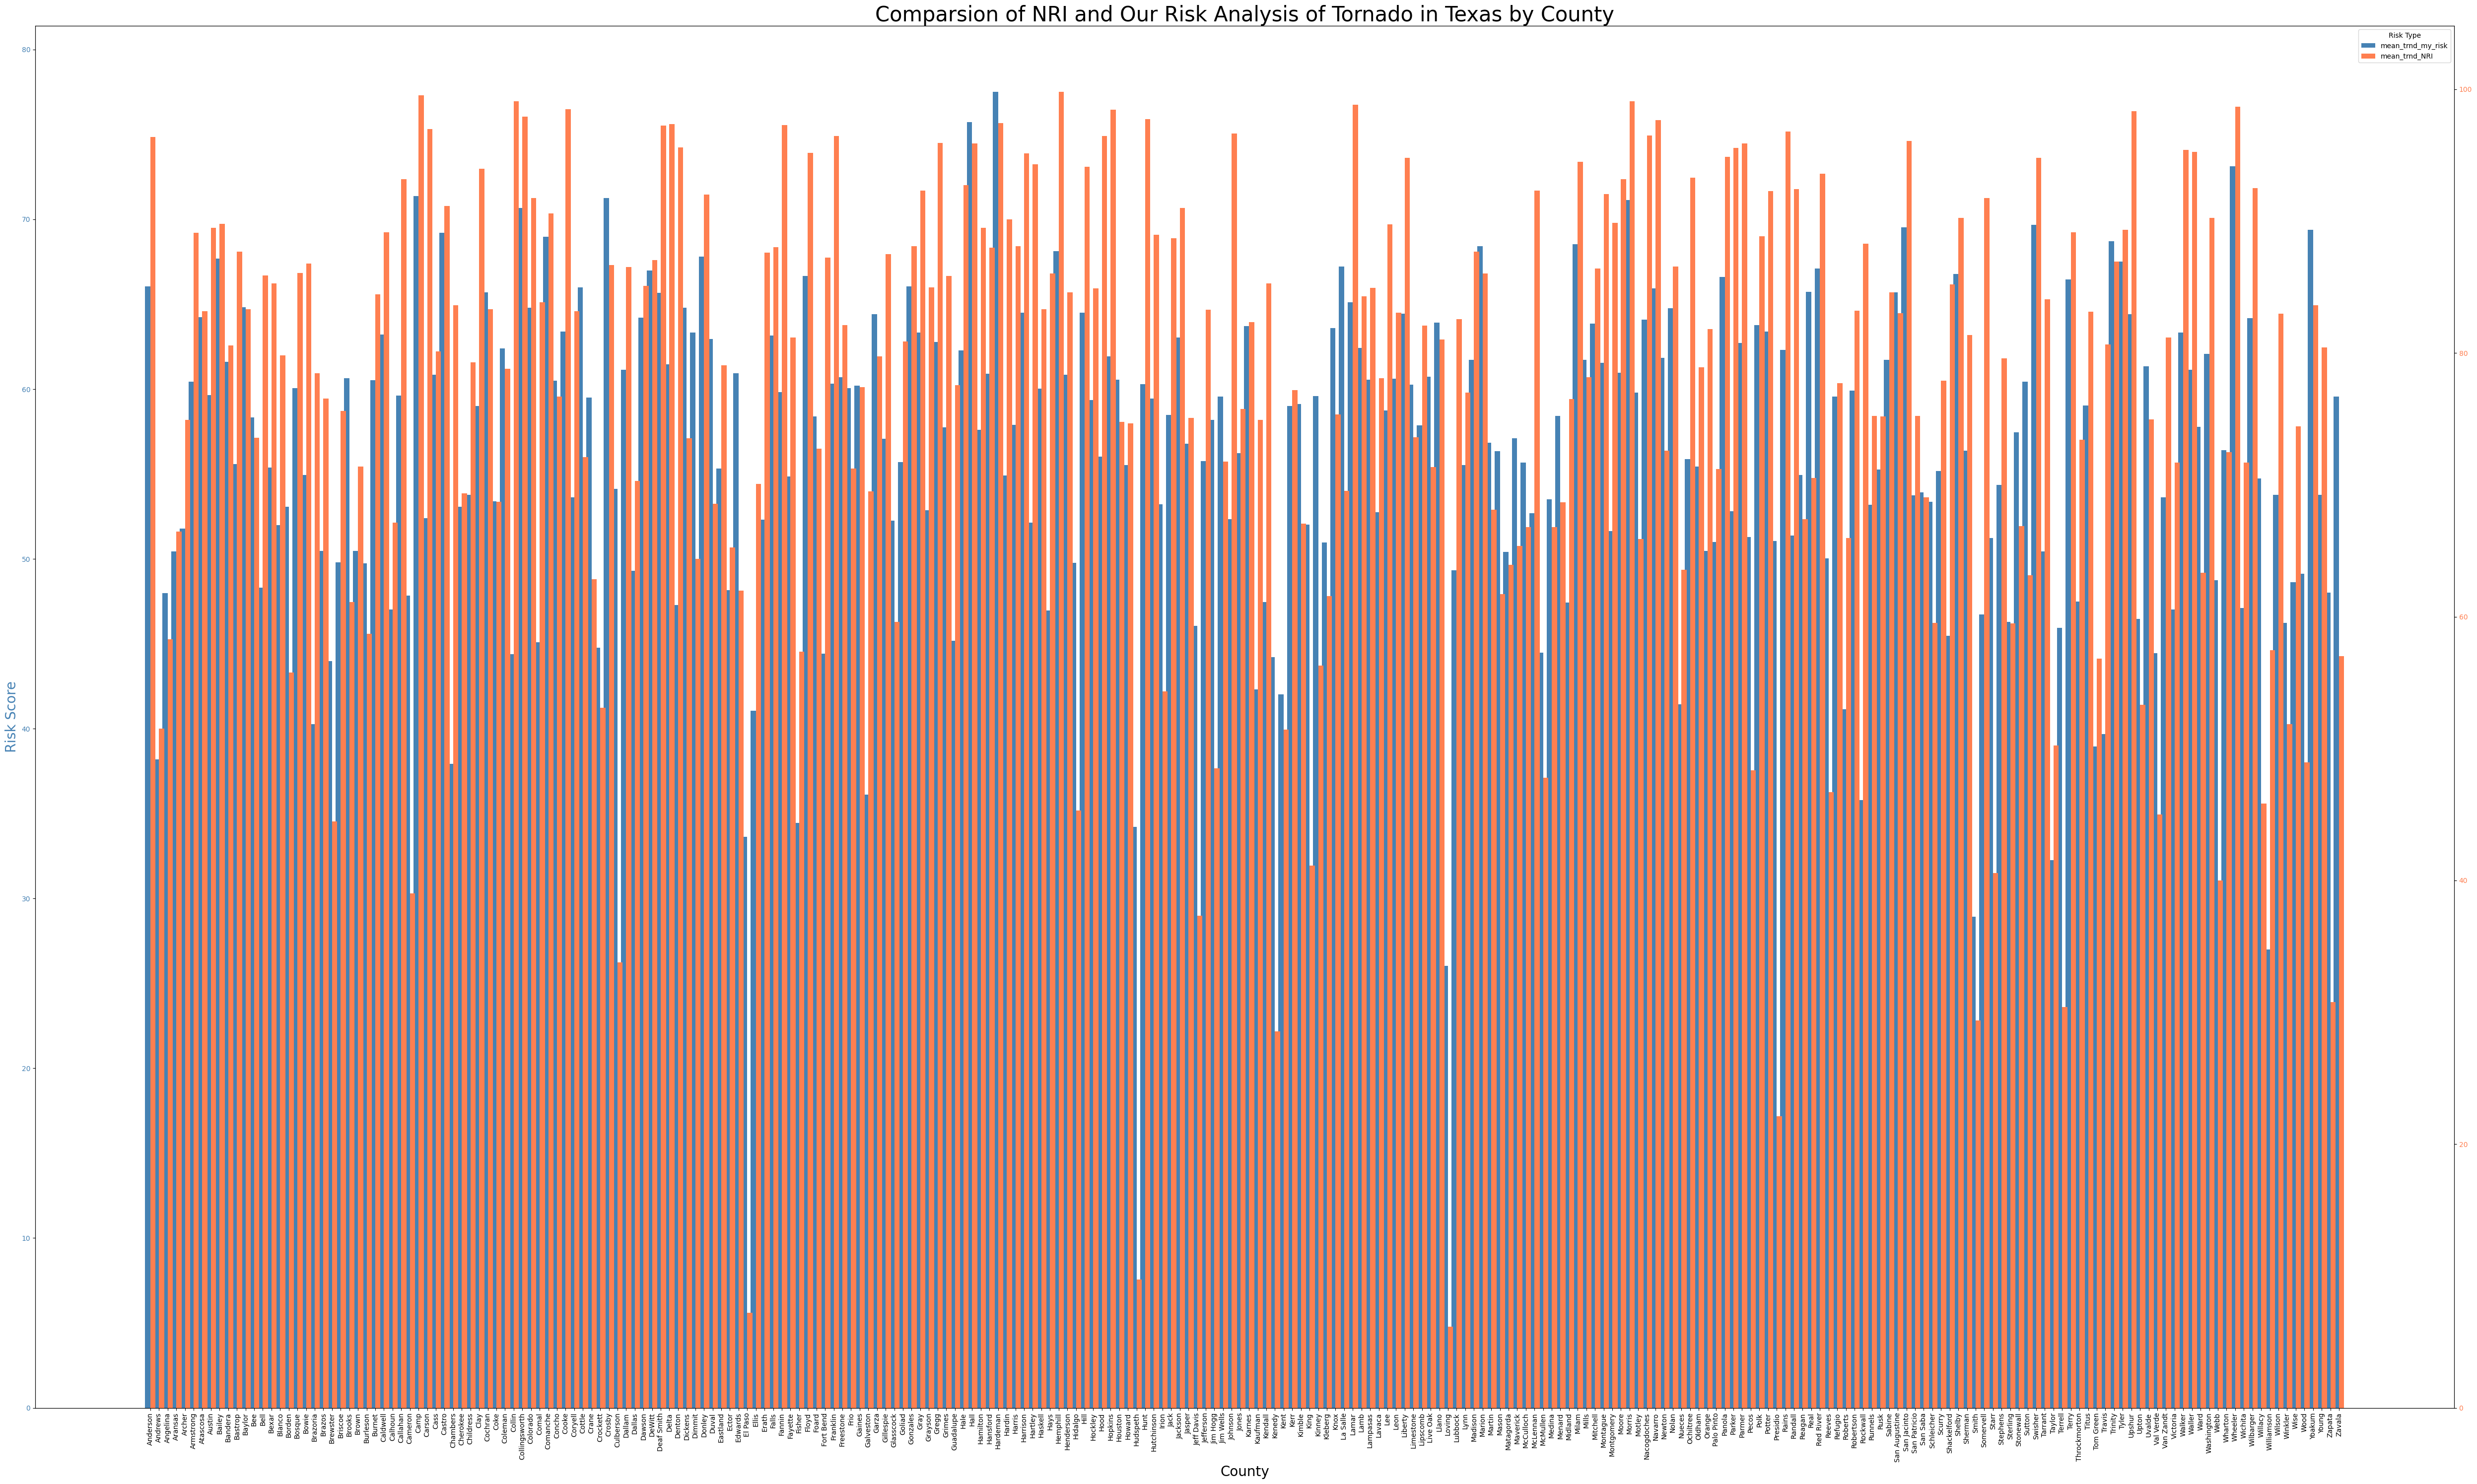

In [46]:
fig, ax1 = plt.subplots(figsize=(50,30))

x = range(len(grouped_data_tx))
width = 0.6
ax1.bar([i-width/2 for i in x], grouped_data_tx.iloc[:, 0], width=width, color ='steelblue', label=grouped_data_tx.columns[0])
ax1.set_ylabel('Risk Score', color='steelblue', fontsize = 20)
ax1.tick_params(axis='y', labelcolor='steelblue')

ax2 = ax1.twinx()
ax2.bar([i + width/2 for i in x], grouped_data_tx.iloc[:, 1], width=width, color='coral', label=grouped_data_tx.columns[1])
ax2.tick_params(axis = 'y', labelcolor = 'coral')

ax1.set_xticks(x)
ax1.set_xticklabels(grouped_data_tx.index, rotation = 90)
ax1.set_xlabel('County', fontsize = 20)

plt.title('Comparsion of NRI and Our Risk Analysis of Tornado in Texas by County', fontsize = 30)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, title = 'Risk Type')

plt.tight_layout()
plt.show()

# Geopanda Map for Colorado Showing NRI and Our Risk Scores for Lightning by County

In [37]:
## Read the Census Tracts data
tracts = gpd.read_file('NRI_Shapefile_CensusTracts.shp')

##Verifications for Shape files
tracts.head()

###This checks for Coordinate Reference System (CRS)
tracts.crs
###Checks the geometries in the data
tracts.geometry.head()

0    POLYGON ((-9626784.493 3827718.774, -9626802.4...
1    POLYGON ((-9625497.973 3827700.43, -9625504.76...
2    POLYGON ((-9623646.617 3823891.992, -9623666.3...
3    POLYGON ((-9622012.001 3826514.039, -9622007.2...
4    POLYGON ((-9619304.709 3823820.353, -9619304.3...
Name: geometry, dtype: geometry

In [38]:
### Cleaning data - Dr. Lane's Example

# Check the projection and set it
tracts_clean = tracts.set_crs(epsg = 4326, inplace = True, allow_override=True)

# 3. Now you can transform to a new CRS (e.g., Pseudo-Mercator)
tracts_clean = tracts_clean.to_crs(epsg = 4326)

# Replace -9999 nulls with NaN

tracts_clean = tracts_clean.replace(-9999, np.nan)

In [39]:
# 1. Tell GeoPandas the data is actually Web Mercator (meters)
tracts_clean.crs = 'EPSG:3857'

# 2. Now properly convert it to degrees to match your xlim/ylim
tracts_clean = tracts_clean.to_crs(epsg=4326)

# Standard projection for US National maps

tracts_clean = tracts_clean.to_crs('ESRI:102003')

tracts_clean.head()

,NRI_ID,STATE,STATEABBRV,STATEFIPS,COUNTY,COUNTYTYPE,COUNTYFIPS,STCOFIPS,TRACT,TRACTFIPS,...,WNTW_ALRP,WNTW_ALRA,WNTW_ALR_N,WNTW_RISKV,WNTW_RISKS,WNTW_RISKR,NRI_VER,Shape_Leng,Shape_Area,geometry
0,T01001020100,Alabama,AL,01,Autauga,County,001,01001,020100,01001020100,...,7.410082e-09,0.000009,32.947366,214.404773,25.882367,Relatively Low,March 2023,19225.811017,1.388551e+07,"POLYGON ((888436.979 -515916.275, 888434.788 -..."
1,T01001020200,Alabama,AL,01,Autauga,County,001,01001,020200,01001020200,...,7.410082e-09,0.000009,33.845738,335.526352,29.020596,Relatively Low,March 2023,11645.802680,4.687259e+06,"POLYGON ((889513.324 -515823.588, 889509.56 -5..."
2,T01001020300,Alabama,AL,01,Autauga,County,001,01001,020300,01001020300,...,7.410082e-09,0.000009,33.386570,494.226826,32.839033,Relatively Low,March 2023,12474.652420,7.550456e+06,"POLYGON ((891382.825 -518869.923, 891366.236 -..."
3,T01001020400,Alabama,AL,01,Autauga,County,001,01001,020400,01001020400,...,7.410082e-09,0.000009,32.654955,517.167844,33.357513,Relatively Low,March 2023,14839.600848,9.007297e+06,"POLYGON ((892526.253 -516527.408, 892530.7 -51..."
4,T01001020501,Alabama,AL,01,Autauga,County,001,01001,020501,01001020501,...,7.410082e-09,0.000009,32.793527,558.901021,34.226799,Relatively Low,March 2023,13543.791893,8.736313e+06,"POLYGON ((895017.426 -518563.572, 895057.475 -..."


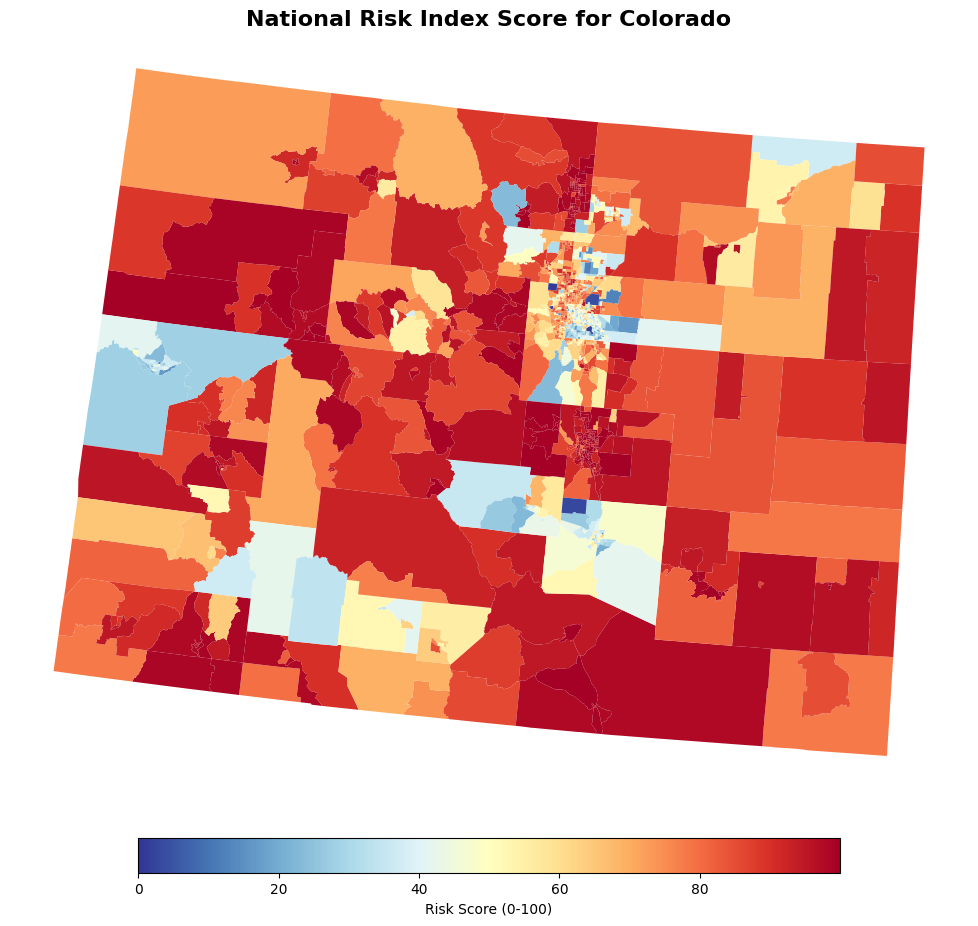

C:\Users\Owner\AppData\Local\Programs\Python\Python314\Lib\site-packages\geopandas\geodataframe.py:1969: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)


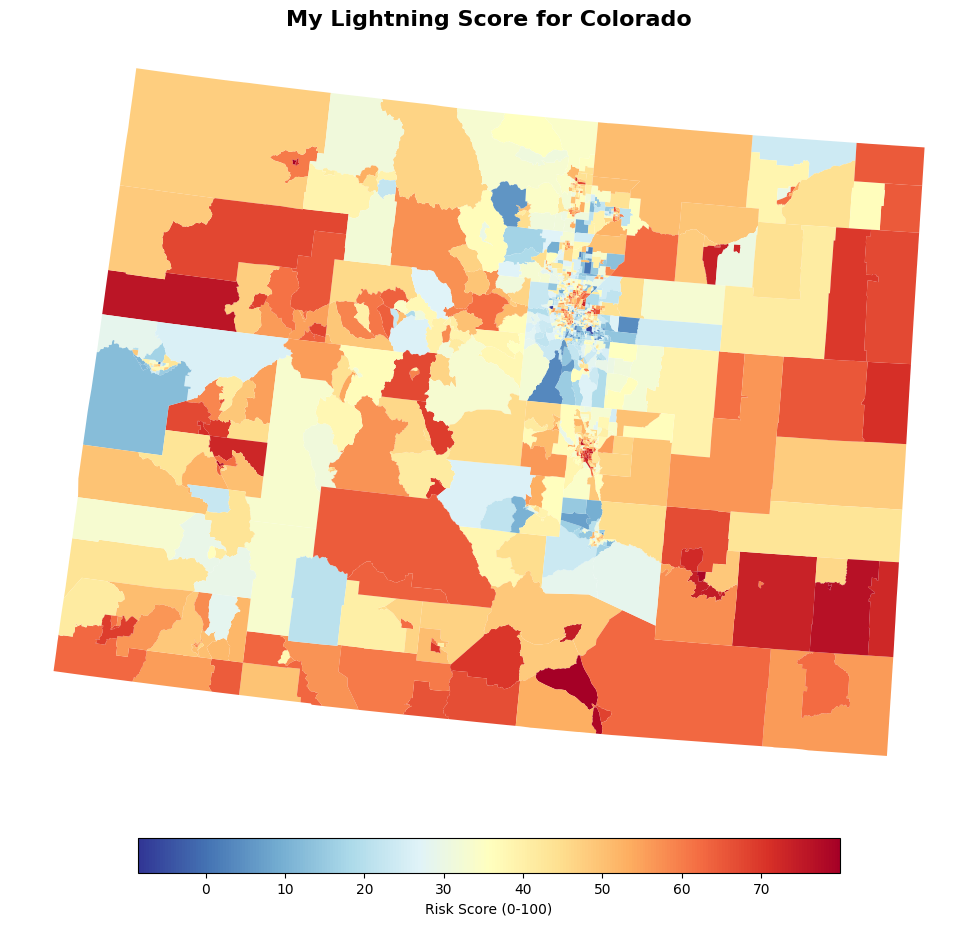

In [40]:
state_name = 'Colorado' 

state_map = tracts_clean[tracts_clean['STATE'] == state_name]
state_map

### Setup the plot
fig, ax = plt.subplots(1, 1, figsize=(12, 10))

state_map.plot(
    column='LTNG_RISKS',
    cmap='RdYlBu_r',
    aspect = 1,
    linewidth=0.0,
    ax=ax,
    legend=True,
    legend_kwds={'label': 'Risk Score (0-100)', 'orientation': 'horizontal', 'shrink': 0.6, 'pad': 0.05},
    missing_kwds={'color': 'lightgrey', 'label': 'No Data'},
)

# 5. Final styling
ax.set_title('National Risk Index Score for Colorado', fontsize = 16, fontweight='bold')
ax.set_axis_off()
plt.tight_layout()
plt.show()


state_name = 'Colorado' 

state_map = tracts_clean[tracts_clean['STATE'] == state_name]
state_map

state_map['CALC_LTNG_RISK'] = (
    (state_map['LTNG_EALS'] * 0.40) +
    (state_map['SOVI_SCORE'] * 0.45) +
    ((1 - state_map['RESL_SCORE']) * 0.15)
)
### Setup the plot
fig, ax = plt.subplots(1, 1, figsize=(12, 10))

state_map.plot(
    column='CALC_LTNG_RISK',
    cmap='RdYlBu_r',
    aspect = 1,
    linewidth=0.0,
    ax=ax,
    legend=True,
    legend_kwds={'label': 'Risk Score (0-100)', 'orientation': 'horizontal', 'shrink': 0.6, 'pad': 0.05},
    missing_kwds={'color': 'lightgrey', 'label': 'No Data'},
)

# 5. Final styling
ax.set_title('My Lightning Score for Colorado', fontsize = 16, fontweight='bold')
ax.set_axis_off()
plt.tight_layout()
plt.show()


# Geopanda Map for Texas Showing NRI and Our Risk Scores for Heat Wave by County

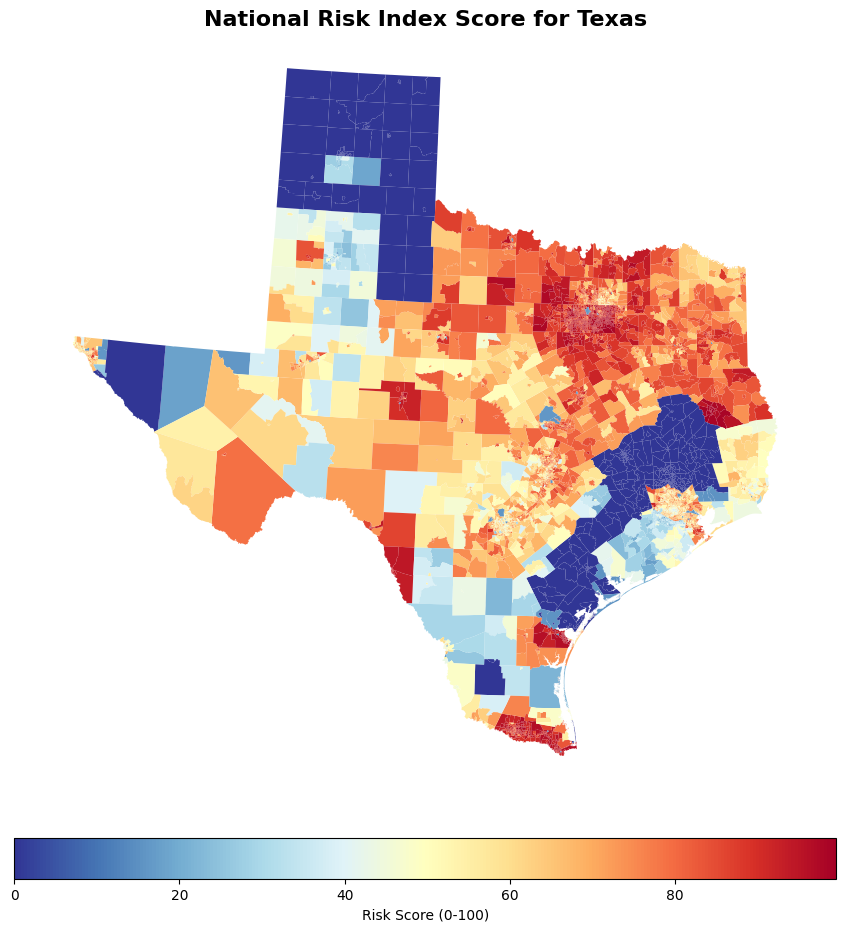

C:\Users\Owner\AppData\Local\Programs\Python\Python314\Lib\site-packages\geopandas\geodataframe.py:1969: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)


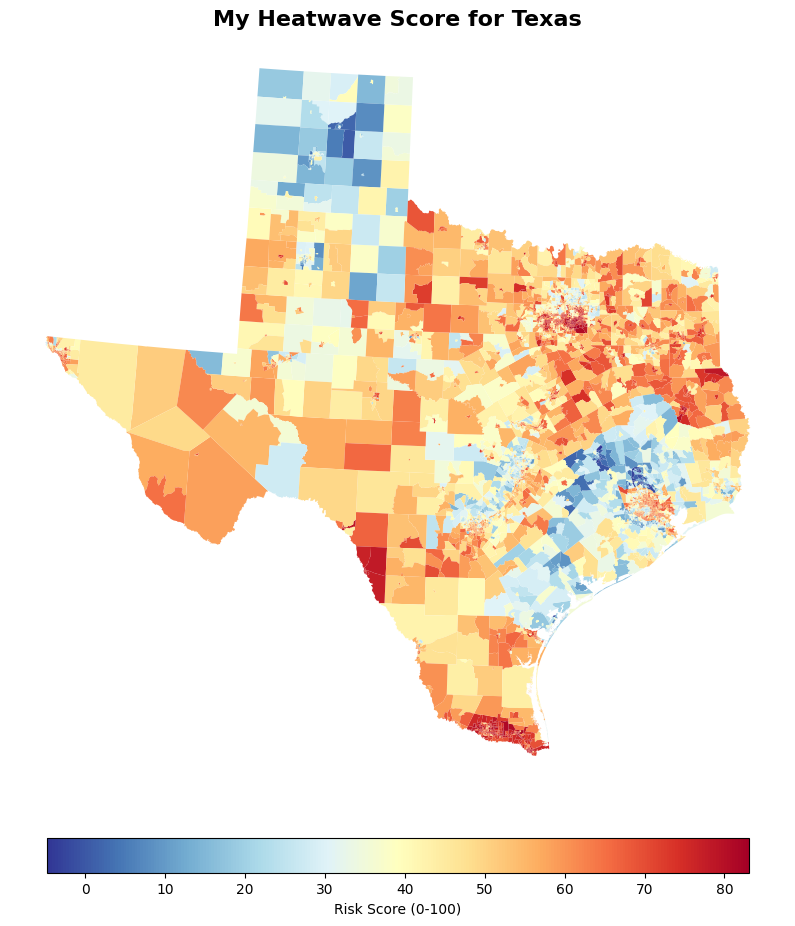

In [50]:
state_name = 'Texas' 

state_map = tracts_clean[tracts_clean['STATE'] == state_name]
state_map

### Setup the plot
fig, ax = plt.subplots(1, 1, figsize=(14, 10))

state_map.plot(
    column='HWAV_RISKS',
    cmap='RdYlBu_r',
    aspect = 1,
    linewidth=0.0,
    ax=ax,
    legend=True,
    legend_kwds={'label': 'Risk Score (0-100)', 'orientation': 'horizontal', 'shrink': 0.6, 'pad': 0.05},
    missing_kwds={'color': 'lightgrey', 'label': 'No Data'},
)

# 5. Final styling
ax.set_title('National Risk Index Score for Texas', fontsize = 16, fontweight='bold')
ax.set_axis_off()
plt.tight_layout()
plt.show()


state_name = 'Texas' 

state_map = tracts_clean[tracts_clean['STATE'] == state_name]
state_map

state_map['CALC_HWAV_RISK'] = (
    (state_map['HWAV_EALS'] * 0.40) +
    (state_map['SOVI_SCORE'] * 0.45) +
    ((1 - state_map['RESL_SCORE']) * 0.15)
)
### Setup the plot
fig, ax = plt.subplots(1, 1, figsize=(12, 10))

state_map.plot(
    column='CALC_HWAV_RISK',
    cmap='RdYlBu_r',
    aspect = 1,
    linewidth=0.0,
    ax=ax,
    legend=True,
    legend_kwds={'label': 'Risk Score (0-100)', 'orientation': 'horizontal', 'shrink': 0.6, 'pad': 0.05},
    missing_kwds={'color': 'lightgrey', 'label': 'No Data'},
)

# 5. Final styling
ax.set_title('My Heatwave Score for Texas', fontsize = 16, fontweight='bold')
ax.set_axis_off()
plt.tight_layout()
plt.show()
